# MACHINE LEARNING ASSIGNMENT: Customer Segmentation and Purchase Prediction
Name: Chetna Mahajan

Date: 06-02-2026

## Part 1: Data Exploration and pre-processing

In [ ]:
### 1.1 Load & inspect-

import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import seaborn as sns

# Load the dataset using pandas

customer_data= pd.read_csv('/content/drive/MyDrive/Chetna_Mahajan_Assignment4+5+6/customer_data.csv')

Mounted at /content/drive


In [ ]:
# Display the first 10 rows
customer_data.head(10)

,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
0,CUST000878,29.0,Female,Tier 3,Silver,465.00,11,42.27,50.0,18.0,4,15.53,0
1,CUST004886,47.0,Male,Tier 1,Platinum,4451.32,23,193.54,16.0,38.0,6,404.45,1
2,CUST002485,37.0,Male,Tier 1,Platinum,1903.02,21,90.62,29.0,28.0,5,207.83,0
3,CUST002289,37.0,Male,Tier 1,Platinum,3952.75,23,171.86,33.0,31.0,11,502.30,1
4,CUST000812,25.0,Male,Tier 1,Silver,1367.07,11,124.28,46.0,18.0,7,70.93,0
5,CUST000249,36.0,Female,Tier 2,Silver,160.15,6,26.69,39.0,8.0,3,8.96,0
6,CUST003299,32.0,Male,Tier 2,Gold,3440.79,17,202.40,29.0,29.0,6,304.40,1
7,CUST000107,37.0,Female,Tier 1,Silver,505.17,6,84.20,51.0,15.0,4,16.93,0
8,CUST000280,26.0,Female,Tier 3,Silver,2476.96,9,275.22,44.0,10.0,4,71.01,0
9,CUST001282,27.0,NaN,Tier 1,Silver,404.24,12,33.69,56.0,17.0,8,26.07,0


In [ ]:
# Check the shape of the dataset
customer_data.shape

(5025, 13)

In [ ]:
# Display data types and check for null values using info
customer_data.dtypes

,0
customer_id,object
age,float64
gender,object
city_tier,object
membership_type,object
total_spend,float64
num_transactions,int64
avg_transaction_value,float64
days_since_last_purchase,float64
num_visits,float64


In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   5025 non-null   object 
 1   age                           4723 non-null   float64
 2   gender                        4724 non-null   object 
 3   city_tier                     5025 non-null   object 
 4   membership_type               5025 non-null   object 
 5   total_spend                   5025 non-null   float64
 6   num_transactions              5025 non-null   int64  
 7   avg_transaction_value         5025 non-null   float64
 8   days_since_last_purchase      4723 non-null   float64
 9   num_visits                    4724 non-null   float64
 10  product_categories_purchased  5025 non-null   int64  
 11  discount_used                 5025 non-null   float64
 12  high_value_customer           5025 non-null   int64  
dtypes: 

In [ ]:
# Generate summary statistics using describe
customer_data.describe()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
count,4723.000000,5025.000000,5025.000000,5025.000000,4723.000000,4724.000000,5025.000000,5025.000000,5025.000000
mean,39.279483,3520.270324,15.047761,219.407385,29.456490,23.032599,6.714030,308.958681,0.373731
std,11.608329,3503.705187,7.628706,167.171094,13.163085,10.362527,3.162972,373.824281,0.483842
min,18.000000,11.590000,1.000000,1.770000,4.000000,3.000000,1.000000,0.430000,0.000000
25%,30.000000,1031.970000,9.000000,99.830000,19.000000,15.000000,4.000000,61.530000,0.000000
50%,38.000000,2258.380000,14.000000,176.020000,26.000000,21.000000,6.000000,166.820000,0.000000
75%,47.000000,4777.600000,20.000000,291.620000,41.000000,30.000000,9.000000,405.600000,1.000000
max,75.000000,27621.780000,43.000000,1500.110000,69.000000,59.000000,15.000000,3999.660000,1.000000


In [ ]:
### 1.2 Handle Missing values

# Identify columns with missing values
missing_cols = pd.DataFrame({
    'Missing Count': customer_data.isnull().sum(),
    'Missing %': customer_data.isnull().sum() / len(customer_data) * 100
})

# sort by Missing % in descending order
missing_cols = missing_cols.sort_values(by='Missing %', ascending=False)

print(missing_cols)


                              Missing Count  Missing %
age                                     302    6.00995
days_since_last_purchase                302    6.00995
gender                                  301    5.99005
num_visits                              301    5.99005
customer_id                               0    0.00000
membership_type                           0    0.00000
city_tier                                 0    0.00000
num_transactions                          0    0.00000
total_spend                               0    0.00000
avg_transaction_value                     0    0.00000
product_categories_purchased              0    0.00000
discount_used                             0    0.00000
high_value_customer                       0    0.00000


In [ ]:
# Fill numerical columns with median values
num_cols= customer_data.select_dtypes(include=['int64', 'float64']).columns
customer_data[num_cols]= customer_data[num_cols].fillna(customer_data[num_cols].median())

# Fill categorical columns with Mode
cat_cols= customer_data.select_dtypes(include=['object', 'category']).columns
for cols in cat_cols:
    customer_data[cols]= customer_data[cols].fillna(customer_data[cols].mode()[0])

# Verify that no missing value remains
print(customer_data.isnull().sum())

customer_id                     0
age                             0
gender                          0
city_tier                       0
membership_type                 0
total_spend                     0
num_transactions                0
avg_transaction_value           0
days_since_last_purchase        0
num_visits                      0
product_categories_purchased    0
discount_used                   0
high_value_customer             0
dtype: int64


In [ ]:
### 1.3 Handle duplicates
# Check for duplicate rows based on customer_id
customer_data['customer_id'].duplicated().any()

np.True_

np.True_: There exists duplicate rows in customer_id

In [ ]:
# Remove duplicate rows
duplicates_removed = customer_data.duplicated(subset='customer_id').sum()
customer_data = customer_data.drop_duplicates(subset='customer_id')

# Report the number of duplicates removed
print("Number of duplicate rows removed:", duplicates_removed)


Number of duplicate rows removed: 25


* 25 duplicate rows in customer_id are removed

In [ ]:
### 1.4 Basic Exploratory Analysis
# Use value counts to show the distribution of : gender, membership_type and high_value_customer
def value_counts_table(col):
    return pd.DataFrame({
        'Count': customer_data[col].value_counts(),
        'Percentage (%)': customer_data[col].value_counts(normalize=True) * 100
    }).round(2)

value_counts_table('gender')

,Count,Percentage (%)
gender,,
Female,2639,52.78
Male,2292,45.84
Other,69,1.38


In [ ]:
value_counts_table('membership_type')

,Count,Percentage (%)
membership_type,,
Silver,1959,39.18
Gold,1911,38.22
Platinum,1130,22.60


In [ ]:
value_counts_table('high_value_customer')

,Count,Percentage (%)
high_value_customer,,
0,3129,62.58
1,1871,37.42


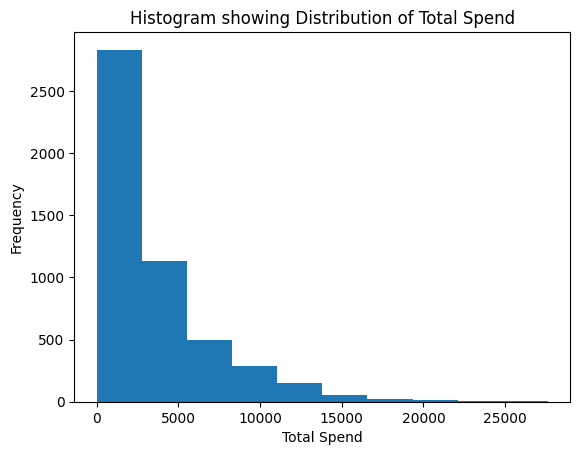

In [ ]:
# Create 2 visualisations using seabormm or matplotlib
# Histogram showing distribution of total_spend
import matplotlib.pyplot as plt

plt.hist(customer_data['total_spend'].dropna(), bins=10)
plt.xlabel('Total Spend')
plt.ylabel('Frequency')
plt.title('Histogram showing Distribution of Total Spend')
plt.show()



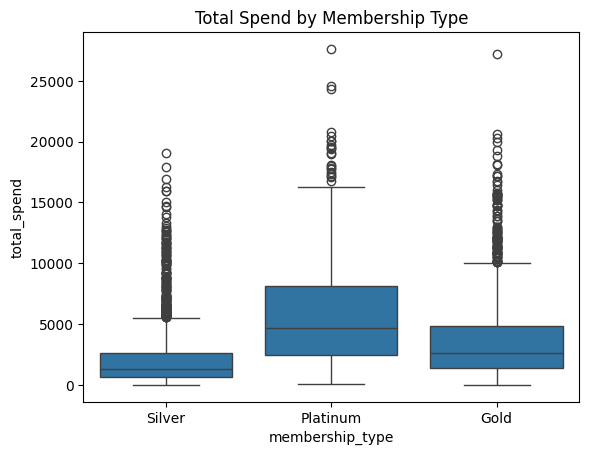

In [ ]:
# Box plot comparing total_spend across different membership_types

plt.figure()
sns.boxplot(
    x='membership_type',
    y='total_spend',
    data=customer_data
)
plt.title('Total Spend by Membership Type')
plt.show()



* The histogram shows a positive right skewed distribution of total spend which means most of the customers are low spenders in the range of 5000 whereas few customers are in the range of high spend which are high value or premium customers.
The Box plot shows that membership type is a strong predictor of total spend. The Platinum members have high median and variability followed by Gold and Silver membership. The outliers are also extreme in platinum members followed by Gold and Silver.
Hence it is important to scale the data before clusterring.

## PART 2: Customer Segmentation using clustering

In [ ]:
### 2.1 Prepare data for Clustering
# Select numerical features for customer Segmentation
numerical_features= customer_data[['age', 'total_spend', 'num_transactions', 'avg_transaction_value', 'days_since_last_purchase', 'num_visits']]
print(numerical_features)

       age  total_spend  num_transactions  avg_transaction_value  \
0     29.0       465.00                11                  42.27   
1     47.0      4451.32                23                 193.54   
2     37.0      1903.02                21                  90.62   
3     37.0      3952.75                23                 171.86   
4     25.0      1367.07                11                 124.28   
...    ...          ...               ...                    ...   
5020  38.0     16708.59                22                 759.48   
5021  31.0       544.70                 5                 108.94   
5022  41.0      1438.83                12                 119.90   
5023  44.0      9543.98                32                 298.25   
5024  29.0       571.53                 9                  63.50   

      days_since_last_purchase  num_visits  
0                         50.0        18.0  
1                         16.0        38.0  
2                         29.0        28.0  
3  

In [ ]:
# Apply standard scaling to normalise all selected features
scaler= StandardScaler()
num_scaled= scaler.fit_transform(numerical_features)
num_scaled

array([[-0.90631755, -0.8719261 , -0.52917369, -1.05984339,  1.62204464,
        -0.48757685],
       [ 0.69256475,  0.2655669 ,  1.04488915, -0.155375  , -1.03617339,
         1.50334537],
       [-0.19570319, -0.46158832,  0.78254534, -0.77075073, -0.01979591,
         0.50788426],
       ...,
       [ 0.15960398, -0.59404454, -0.39800179, -0.59568076, -0.25434456,
        -0.38803074],
       [ 0.42608437,  1.71875307,  2.22543628,  0.47070343, -0.56707609,
         2.00107592],
       [-0.90631755, -0.84152785, -0.7915175 , -0.9329057 ,  1.07476446,
        -1.08485352]])

. Standard Scaling is necessary before clustering to ensure all the features are at a equal distance from mean and contribute equally to distance calculations in clustering algorithms.

In [ ]:
### 2.2 Determine optimal number of clusters (k)
# Implement k-means clustering for k value ranging from 2-8

wcss=[]
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(num_scaled)
    wcss.append(km.inertia_)


In [ ]:
# calculating WCSS for each k value

for k, value in zip(range(2, 8), wcss):
    print(f"k = {k}, WCSS = {value}")


k = 2, WCSS = 16570.382094922603
k = 3, WCSS = 11729.474687073387
k = 4, WCSS = 9809.301713018076
k = 5, WCSS = 8606.708493235734
k = 6, WCSS = 8014.113992576832
k = 7, WCSS = 7513.319808228777


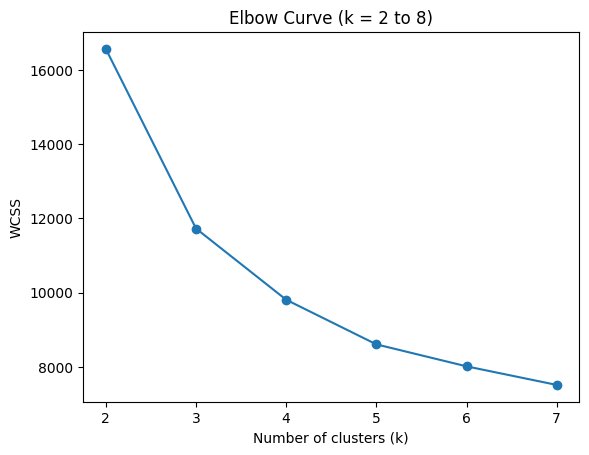

In [ ]:
# ELBOW plot curve WCSS v/s No. of Clusters

plt.plot(range(2, 8), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Curve (k = 2 to 8)')
plt.show()


. The WCSS decreases sharply till k= 4 and then it started to flatten showing that the results are diminishing beyond this point. Hence choosen k=4

In [ ]:
### 2.3 Apply k-means and Profile Segments
# Apply k-means clusterring with k=4
optimal_k= 4
numerical_features= numerical_features.copy()
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
numerical_features["Cluster"] = kmeans.fit_predict(num_scaled)
numerical_features.head()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,Cluster
0,29.0,465.00,11,42.27,50.0,18.0,1
1,47.0,4451.32,23,193.54,16.0,38.0,2
2,37.0,1903.02,21,90.62,29.0,28.0,0
3,37.0,3952.75,23,171.86,33.0,31.0,0
4,25.0,1367.07,11,124.28,46.0,18.0,1


In [ ]:
# Add cluster label as new column 'customer_segment' in the original dataframe

customer_data['Customer_segment'] = numerical_features['Cluster']
customer_data.head()

,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer,Customer_segment
0,CUST000878,29.0,Female,Tier 3,Silver,465.00,11,42.27,50.0,18.0,4,15.53,0,1
1,CUST004886,47.0,Male,Tier 1,Platinum,4451.32,23,193.54,16.0,38.0,6,404.45,1,2
2,CUST002485,37.0,Male,Tier 1,Platinum,1903.02,21,90.62,29.0,28.0,5,207.83,0,0
3,CUST002289,37.0,Male,Tier 1,Platinum,3952.75,23,171.86,33.0,31.0,11,502.30,1,0
4,CUST000812,25.0,Male,Tier 1,Silver,1367.07,11,124.28,46.0,18.0,7,70.93,0,1


In [ ]:
# Display the count of customers in each cluster
cluster_counts = (
    numerical_features['Cluster']
    .value_counts()
    .reset_index()
)

cluster_counts.columns = ['Cluster', 'Customer_Count']
cluster_counts

,Cluster,Customer_Count
0,0,1947
1,1,1742
2,2,816
3,3,495


In [ ]:
# Calculate the mean value of key features for each cluster using groupby

cluster_summary = numerical_features.groupby('Cluster').mean()
cluster_summary


,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits
Cluster,,,,,,
0,41.487930,2829.547149,14.852594,202.212537,24.506934,22.626091
1,28.504018,997.751871,7.960964,145.085121,43.936280,13.541332
2,50.495098,5814.068358,26.519608,221.914522,16.615196,37.772059
3,49.254545,11336.849354,21.707071,545.660606,17.082828,32.375758


  Cluster 0 represents low spending customers with lower average income.
  Cluster 1 represents low spending customers with lower number of transactions, average transaction value and less number of visits.
  Cluster 2 represents moderate spending customers with high engagement in num_visits and number of transactions.
  Cluster 3 represents premium customers with high total spend.

PART 3: Predictive Modeling

In [ ]:
### 3.1 Feature Engineering
numerical_features['spend_per_visit']= (numerical_features['total_spend']/ numerical_features['num_visits']).replace(0, np.nan)

numerical_features['discount_percentage']= (customer_data['discount_used']/ numerical_features['total_spend']).replace(0, np.nan)

numerical_features.head()

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,Cluster,spend_per_visit,discount_percentage
0,29.0,465.00,11,42.27,50.0,18.0,1,25.833333,0.033398
1,47.0,4451.32,23,193.54,16.0,38.0,2,117.140000,0.090861
2,37.0,1903.02,21,90.62,29.0,28.0,0,67.965000,0.109211
3,37.0,3952.75,23,171.86,33.0,31.0,0,127.508065,0.127076
4,25.0,1367.07,11,124.28,46.0,18.0,1,75.948333,0.051885


- Adding two new feaures 'spend_per_visit' and 'discount_percentage' will help us to understand customer behaviour.
'spend_per_visit' will tell us how the customer spends- high spend in few visits or low spend but multiple visits.
'discount_percentage' will tell us whether a customer buys because of discounts or irrespective of discounts. Helps to identify discount driven customers and loyal/ ready to pay full price customers.


In [ ]:
## 3.2 Data preparation for modeling
X= customer_data.drop(columns= ['high_value_customer', 'customer_id'])
Y= customer_data['high_value_customer']
print("Feature matrix shape:", X.shape)
print("Target vector shape :", Y.shape)


Feature matrix shape: (5000, 12)
Target vector shape : (5000,)


In [ ]:
# Split the data into training(80%) and test(20%) sets with random_state= 42
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state= 42, stratify=Y
)

In [ ]:
# Applying One Hot Encoding to categorical features- gender, city_tier, membership_type

categorical_features= ['gender', 'city_tier', 'membership_type']
enco= OneHotEncoder(sparse_output= False)

X_train_enco= enco.fit_transform(X_train[categorical_features])
X_test_enco= enco.transform(X_test[categorical_features])

X_train_encoded_df = pd.DataFrame(
    X_train_enco,
    columns=enco.get_feature_names_out(categorical_features),
    index=X_train.index
)
X_test_encoded_df= pd.DataFrame(
    X_test_enco,
    columns=enco.get_feature_names_out(categorical_features),
    index= X_test.index
)
X_train_encoded_df.columns
X_test_encoded_df.columns


Index(['gender_Female', 'gender_Male', 'gender_Other', 'city_tier_Tier 1',
       'city_tier_Tier 2', 'city_tier_Tier 3', 'membership_type_Gold',
       'membership_type_Platinum', 'membership_type_Silver'],
      dtype='object')

In [ ]:
# apply standard scaling to numerical features in training data to avoid data leakage
numerical_features = X_train.drop(columns=categorical_features).columns.tolist()  # no need to scale cat features as they are in 0 & 1

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numerical_features])
X_test_scaled = scaler.transform(X_test[numerical_features])

In [ ]:
# Final number of features after encoding in training data

# Create a DataFrame for scaled numerical features
X_train_numerical_df = pd.DataFrame(X_train_scaled, columns=numerical_features, index=X_train.index)

# Concatenate the numerical and one-hot encoded categorical features for the training set
X_train_final = pd.concat([X_train_numerical_df, X_train_encoded_df], axis=1)

# Create a DataFrame for scaled numerical features for the test set
X_test_numerical_df = pd.DataFrame(X_test_scaled, columns=numerical_features, index=X_test.index)

# Concatenate the numerical and one-hot encoded categorical features for the test set
X_test_final = pd.concat([X_test_numerical_df, X_test_encoded_df], axis=1)

# Print the final number of features for X_train_final
print("Final number of features after encoding and scaling:", X_train_final.shape[1])

# Print the final number of features for the test set
print("Final number of features in X_test_final:", X_test_final.shape[1])

Final number of features after encoding and scaling: 18
Final number of features in X_test_final: 18


In [ ]:
# Principal Component Analysis for selecting most important features
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

print(f"Original number of features in X_train_final: {X_train_final.shape[1]}")
print(f"Number of features after PCA for X_train_pca: {X_train_pca.shape[1]}")
print(f"Original number of features in X_test_final: {X_test_final.shape[1]}")
print(f"Number of features after PCA for X_test_pca: {X_test_pca.shape[1]}")

Original number of features in X_train_final: 18
Number of features after PCA for X_train_pca: 10
Original number of features in X_test_final: 18
Number of features after PCA for X_test_pca: 10


In [ ]:
## 3.3 Build model
# Build Classification model
ml_model = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42)
}

In [ ]:
# Fit the model on training data

for name, model in ml_model.items():
    model.fit(X_train_pca, Y_train)
    print(f"{name} trained successfully")

Logistic Regression trained successfully


In [ ]:
# Generate predictions on test data
for name, model in ml_model.items():
    Y_pred= model.predict(X_test_pca)

* I have chosen Logistic Regression as Logistic Regression is best where output is either 0 or 1 and here the target variable is high_value_customer which is either Yes/No and in Binary its 0 or 1


In [ ]:
# 3.4 Model Evaluation

metrix_table=[]
for name, model in ml_model.items():
    cm = confusion_matrix(Y_test, Y_pred)
    acc = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred, pos_label=1)
    rec = recall_score(Y_test, Y_pred, pos_label=1)
    f1 = f1_score(Y_test, Y_pred, pos_label=1)

    metrix_table.append({
        "Model": name,
        "Confusion Metrix": cm,
        "Accuracy"        : acc,
        "Precision"       : prec,
        "Recall"          : rec,
        "F1"              : f1
    })

print(
    f"Confusion Matrix:\n{cm}\n"
    f"Accuracy:   {acc}\n"
    f"Precision:  {prec}\n"
    f"Recall:     {rec}\n"
    f"F1 Score:   {f1}"
)


Confusion Matrix:
[[597  29]
 [ 48 326]]
Accuracy:   0.923
Precision:  0.9183098591549296
Recall:     0.8716577540106952
F1 Score:   0.8943758573388203


In [ ]:
# Classification report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       626
           1       0.92      0.87      0.89       374

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.92      1000
weighted avg       0.92      0.92      0.92      1000



### PART 4- Optimisation and Insights

In [ ]:
## 4.1 Hyperparameter Tuning
param_grid = {
    'C': [0.01, 0.1, 1],
    'l1_ratio': [0, 1],
    'solver': ['saga']
}

In [ ]:
# Gridsearchcv with 3 fold cross-validation (cv=3)

lr = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv= 3,
    scoring= 'accuracy'
)
grid.fit(X_train_pca, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1], 'l1_ratio': [0, 1],
                         'solver': ['saga']},
             scoring='accuracy')

In [ ]:
# Report the best parameters found
best_model = grid.best_estimator_
print(best_model)

LogisticRegression(C=1, l1_ratio=0, max_iter=1000, solver='saga')


In [ ]:
# Fit the best model

best_model.fit(X_train_pca, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


LogisticRegression(C=1, l1_ratio=0, max_iter=1000, solver='saga')

In [ ]:
# Evaluate the tuned model on test data
Y_pred_new= best_model.predict(X_test_pca)

In [ ]:
# Performance metrix after tuning
print(classification_report(Y_test, Y_pred_new))


              precision    recall  f1-score   support

           0       0.93      0.95      0.94       626
           1       0.92      0.87      0.89       374

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
# Performance Comparison before and after tuning

initial_accuracy = metrix_table[0]['Accuracy']
initial_f1 = metrix_table[0]['F1']

tuned_accuracy = accuracy_score(Y_test, Y_pred_new)
tuned_f1 = f1_score(Y_test, Y_pred_new, pos_label=1)

print("Performance Comparison:")
print("--------------------------------------------------")
print(f"| Metric      | Before Tuning | After Tuning |")
print("--------------------------------------------------")
print(f"| Accuracy    | {initial_accuracy:.4f}        | {tuned_accuracy:.4f}       |")
print(f"| F1 Score    | {initial_f1:.4f}        | {tuned_f1:.4f}       |")
print("--------------------------------------------------")

Performance Comparison:
--------------------------------------------------
| Metric      | Before Tuning | After Tuning |
--------------------------------------------------
| Accuracy    | 0.9230        | 0.9230       |
| F1 Score    | 0.8944        | 0.8944       |
--------------------------------------------------


In [ ]:
## 4.2 Feature Importance Analysis

# Extract coefficients from the best model (these are for the principal components)
pc_coefficients = best_model.coef_[0]

# Get the PCA components (loadings of original features on principal components)
pca_loadings = pca.components_

# Calculate approximate importance of original features
# This is done by projecting the principal component coefficients back onto the original feature space.
# The result will be a weighted sum where weights are the logistic regression coefficients
# and the components are the PCA loadings.
feature_importances_original = np.dot(pc_coefficients, pca_loadings)

# Get the names of the original features from X_train_final
feature_names = X_train_final.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances_original
})

# Sort by absolute importance to find the most impactful features
feature_importance_df['Absolute_Importance'] = np.abs(feature_importance_df['Importance'])
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Importance', ascending=False)

print(feature_importance_df)

                         Feature  Importance  Absolute_Importance
3          avg_transaction_value    1.581968             1.581968
7                  discount_used    1.526787             1.526787
4       days_since_last_purchase   -1.524191             1.524191
1                    total_spend    1.517940             1.517940
5                     num_visits    0.748627             0.748627
2               num_transactions    0.729768             0.729768
16      membership_type_Platinum    0.367374             0.367374
8               Customer_segment   -0.296642             0.296642
17        membership_type_Silver   -0.262634             0.262634
0                            age    0.123032             0.123032
15          membership_type_Gold   -0.104740             0.104740
10                   gender_Male    0.101047             0.101047
9                  gender_Female   -0.090016             0.090016
6   product_categories_purchased   -0.067719             0.067719
14        

/tmp/ipython-input-2892347090.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


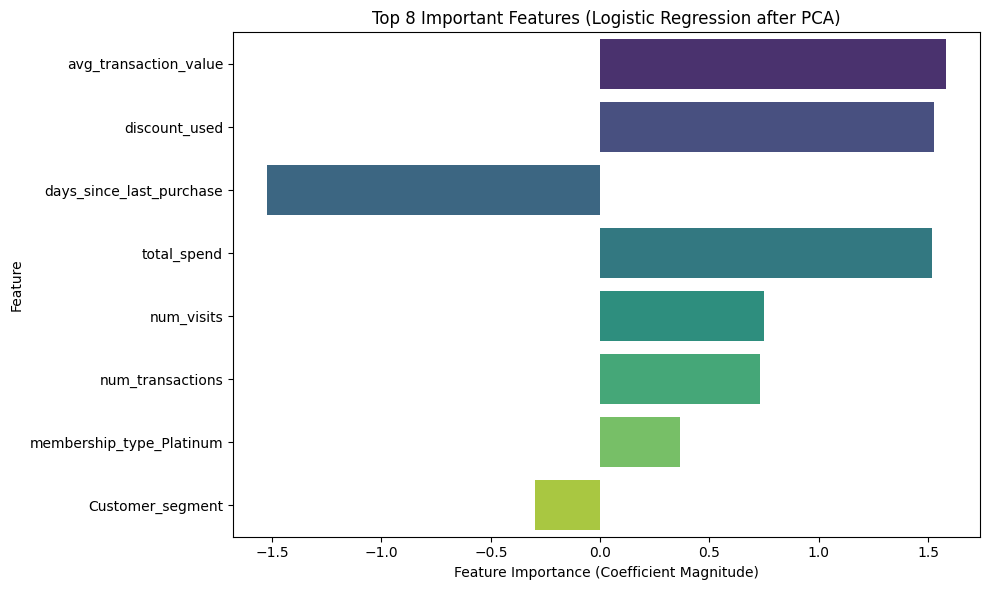

In [ ]:
# Get top 8 features
top_8_features = feature_importance_df.head(8)

# Create the horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_8_features,
    palette='viridis'
)
plt.title('Top 8 Important Features (Logistic Regression after PCA)')
plt.xlabel('Feature Importance (Coefficient Magnitude)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

*

### Distribution of Top Numerical Features Across Customer Segments

/tmp/ipython-input-3938322287.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Customer_segment', y=feature, data=customer_data, palette='viridis')
/tmp/ipython-input-3938322287.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Customer_segment', y=feature, data=customer_data, palette='viridis')
/tmp/ipython-input-3938322287.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Customer_segment', y=feature, data=customer_data, palette='viridis')
/tmp/ipython-input-3938322287.py:16: FutureWarning: 

Passing `palette` without as

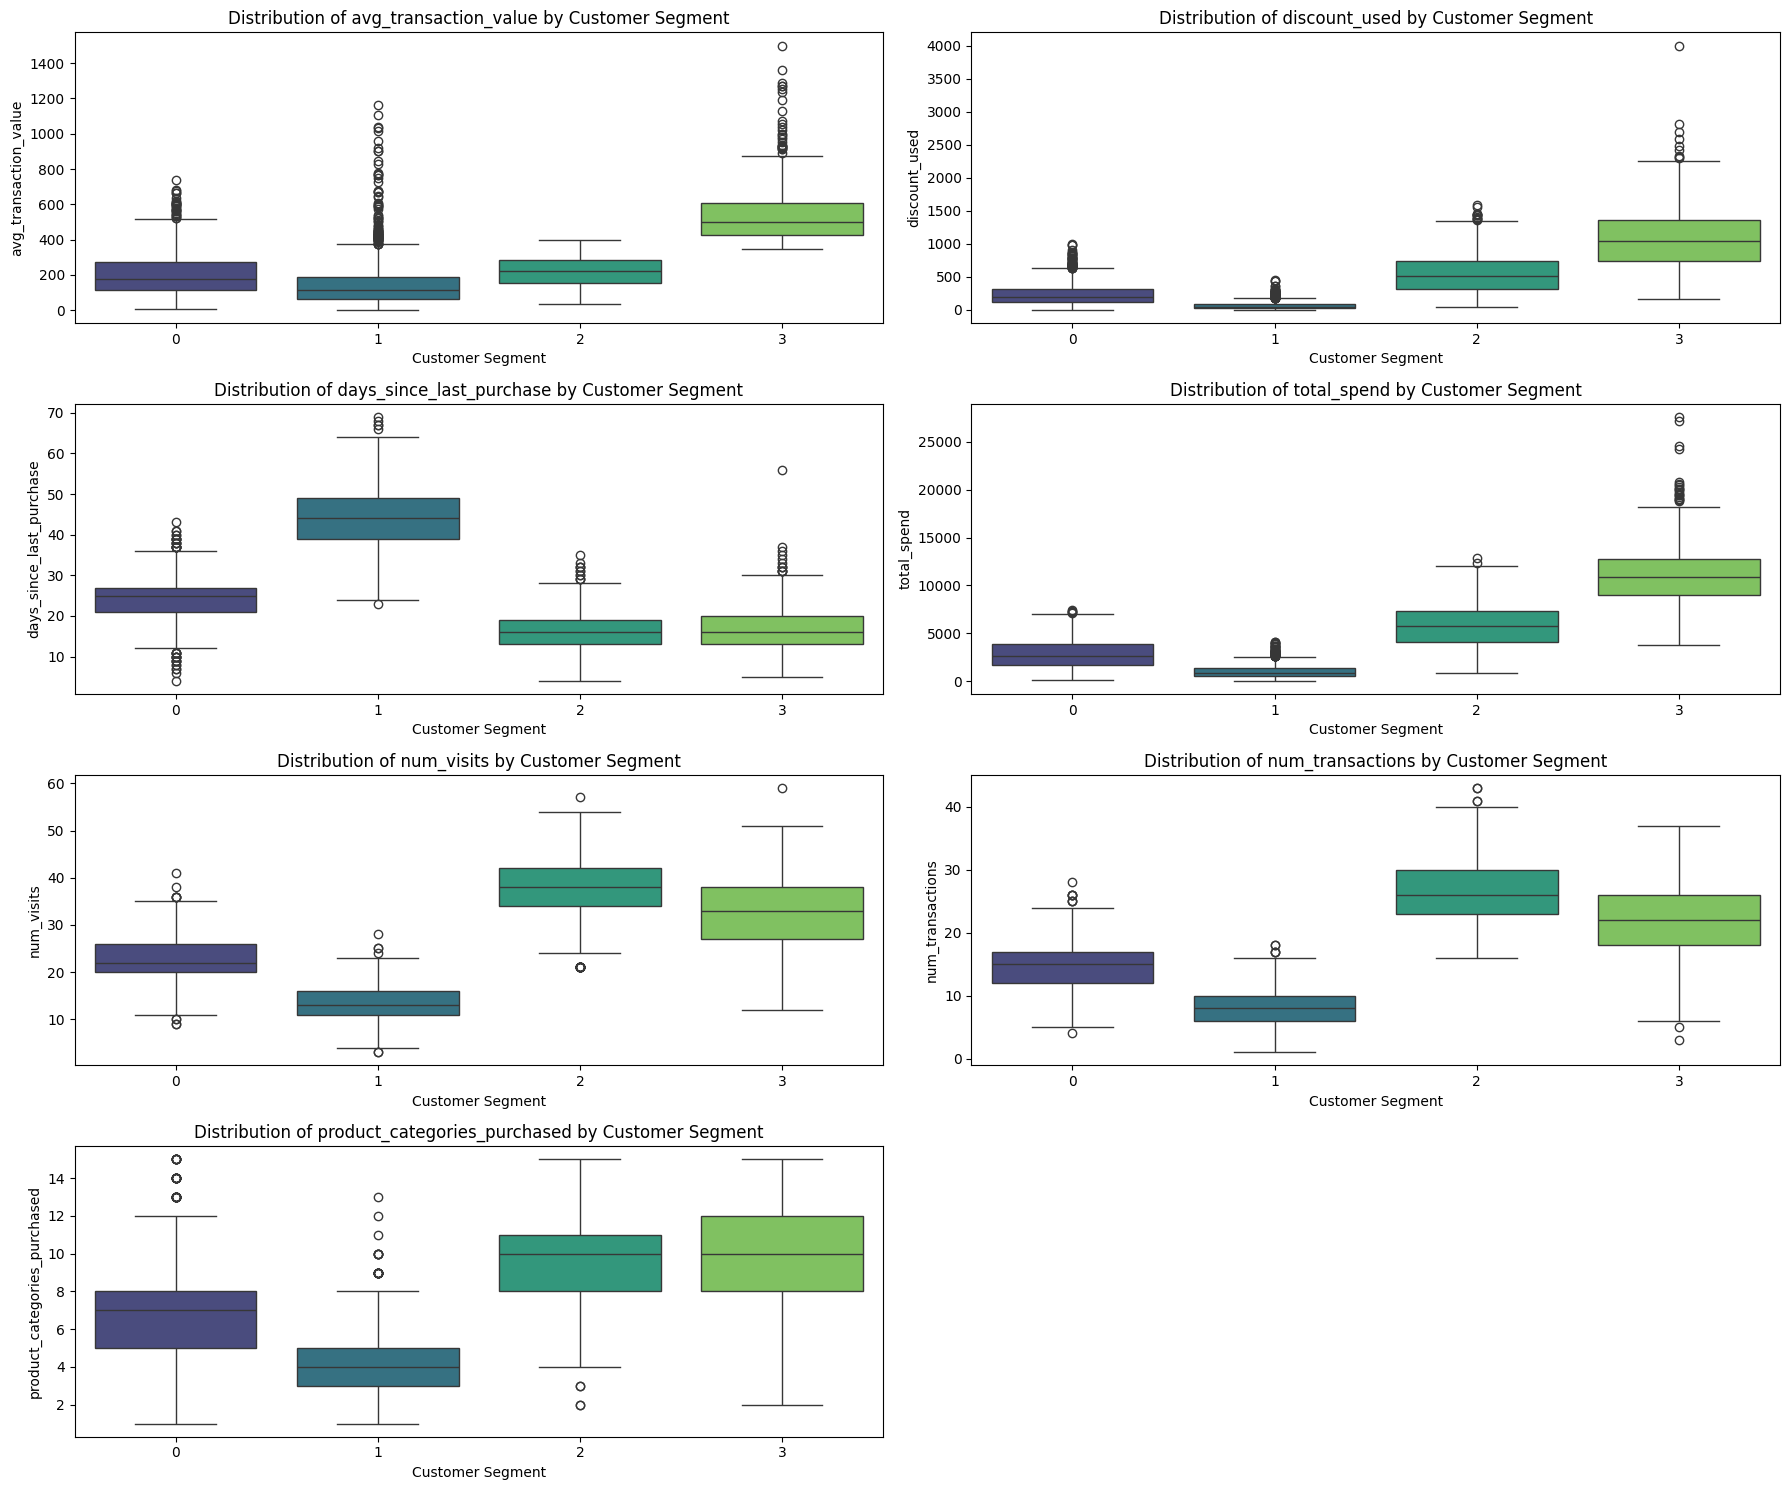

In [ ]:
# Select the top numerical features from the feature importance analysis
top_numerical_features = [
    'avg_transaction_value',
    'discount_used',
    'days_since_last_purchase',
    'total_spend',
    'num_visits',
    'num_transactions',
    'product_categories_purchased'
]

# Create subplots for each top numerical feature
plt.figure(figsize=(18, 15))
for i, feature in enumerate(top_numerical_features):
    plt.subplot(4, 2, i + 1) # Arrange in 4 rows, 2 columns
    sns.boxplot(x='Customer_segment', y=feature, data=customer_data, palette='viridis')
    plt.title(f'Distribution of {feature} by Customer Segment')
    plt.xlabel('Customer Segment')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

## 4.3 Business Recommendations
According to cluster_summary insights during clustering, Cluster 1 customers  show low total_spend, low num_transactions, low num_visits and high days_since_last_purchase.

* Recommendation:Increase customer
engagement, offer exclusive incentives, target value based recommendations and do surveys to understand their needs and reactivate their customer relationship with the brand.


As evident from Box plot between customer_segment and discount_used, Cluster 3 uses the maximum discount coupons followed by cluster 2. This is evident from their high spending and high transaction value purchases.

* Recommendation: Nurture cluster 3 customers with more loyalty pragrammes, early access to new launches and higher rewards to retain them for long term.
Also we can incentivise cluster 2 customers for more spending or upgrade them to premium services to increase their engagement and purchases.

* Recommendation: Boost engagement for Cluster 0 by increasin num_transactions and num_visits as they have less total_spend. Give reawards for repeat purchases, give personalised product suggestions, offer discounts on the products they choose if they shop more.
